## FPPool Interpretability

The public `chemprop.interpret` API exposes family-agnostic FPPool explanations and visualization helpers. This notebook shows the supported molecule-only workflow for a small batched FPPool forward pass, then extracts inner/inter/global explanations and renders the strongest highlighted substructures.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from rdkit import Chem

from chemprop.data import FPPoolBatch, FPPoolConfig, build_fppool_atom_fp
from chemprop.interpret import (
    draw_fppool_bit_highlight,
    draw_fppool_inner_explanations,
    extract_fppool_explanation,
    plot_fppool_global_weights,
    plot_fppool_inter_summary,
)
from chemprop.nn import FPPoolAggregation


This example uses a small multi-family configuration so the explanation API stays aligned with the broader `atoms + morgan + rdkit + pubchem` FPPool path.

In [2]:
torch.manual_seed(7)

mols = [Chem.MolFromSmiles('CCO'), Chem.MolFromSmiles('c1ccccc1O')]
config = FPPoolConfig(
    family_names=('morgan', 'rdkit', 'pubchem'),
    morgan_nbits=64,
    rdkit_nbits=64,
    atoms_repr=True,
)

atom_fp_blocks = [build_fppool_atom_fp(mol, config) for mol in mols]
atom_fp = torch.from_numpy(np.concatenate(atom_fp_blocks, axis=0))
atom_counts = [mol.GetNumAtoms() for mol in mols]
molecule_atom_slices = torch.tensor([0, *torch.tensor(atom_counts).cumsum(0).tolist()])
fppool_batch = FPPoolBatch(
    atom_fp=atom_fp,
    fp_family_lengths=torch.from_numpy(config.family_lengths),
    fp_family_names=list(config.active_family_names),
    molecule_atom_slices=molecule_atom_slices,
)

hidden_dim = 8
H = torch.randn(atom_fp.shape[0], hidden_dim)
batch = torch.tensor([0] * atom_counts[0] + [1] * atom_counts[1])

agg = FPPoolAggregation(dim=hidden_dim)
pooled = agg(H, batch, fppool_batch=fppool_batch)
pooled.shape


[14:03:56] DEPRECATION WARNING: please use MorganGenerator
[14:03:56] DEPRECATION WARNING: please use MorganGenerator


torch.Size([2, 8])

After one forward pass, the latest private attention state can be converted into a public explanation payload. The payload is family-agnostic and already carries explicit atom and bond provenance for visualization.

In [3]:
explanations = extract_fppool_explanation(agg, mols, fppool_batch, config, top_k_bits=3)
first_explanation = explanations[0]
first_explanation.global_explanation

[14:03:56] DEPRECATION WARNING: please use MorganGenerator
[14:03:56] DEPRECATION WARNING: please use MorganGenerator


FPPoolGlobalExplanation(family_names=('atoms', 'morgan', 'rdkit', 'pubchem'), family_weights=(0.24370719492435455, 0.2577100098133087, 0.2505345940589905, 0.24804821610450745), family_mask=(True, True, True, True))

In [4]:
[(inter.family_name, inter.family_weight, len(inter.bit_explanations)) for inter in first_explanation.inter_explanations]

[('atoms', 0.24370719492435455, 1),
 ('morgan', 0.2577100098133087, 3),
 ('rdkit', 0.2505345940589905, 3),
 ('pubchem', 0.24804821610450745, 3)]

### Inner-Level Visualization

The top-ranked inner explanations can be rendered as highlighted atom-and-bond substructures.

In [5]:
top_inner = first_explanation.inner_explanations[0]
top_inner

FPPoolInnerExplanation(provenance=FPPoolBitProvenance(family_name='atoms', family_index=0, family_bit_index=0, global_bit_index=0, atom_indices=(0, 1, 2), bond_indices=()), atom_weights=(0.16988281905651093, 0.6391998529434204, 0.19091728329658508), inner_weight_sum=0.9999999552965164, inter_weight=1.0, global_weight=0.24370719492435455, score=0.24370719492435455)

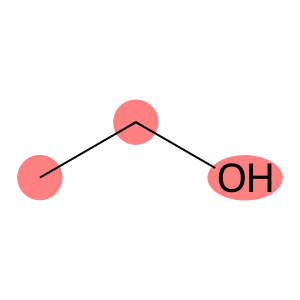

In [6]:
draw_fppool_bit_highlight(mols[0], top_inner)

In [7]:
inner_images = draw_fppool_inner_explanations(mols[0], first_explanation, top_k=3)
len(inner_images), inner_images[0].size

(3, (300, 300))

### Inter-Level Summary

Inter-level summaries group the strongest bit explanations by fingerprint family.

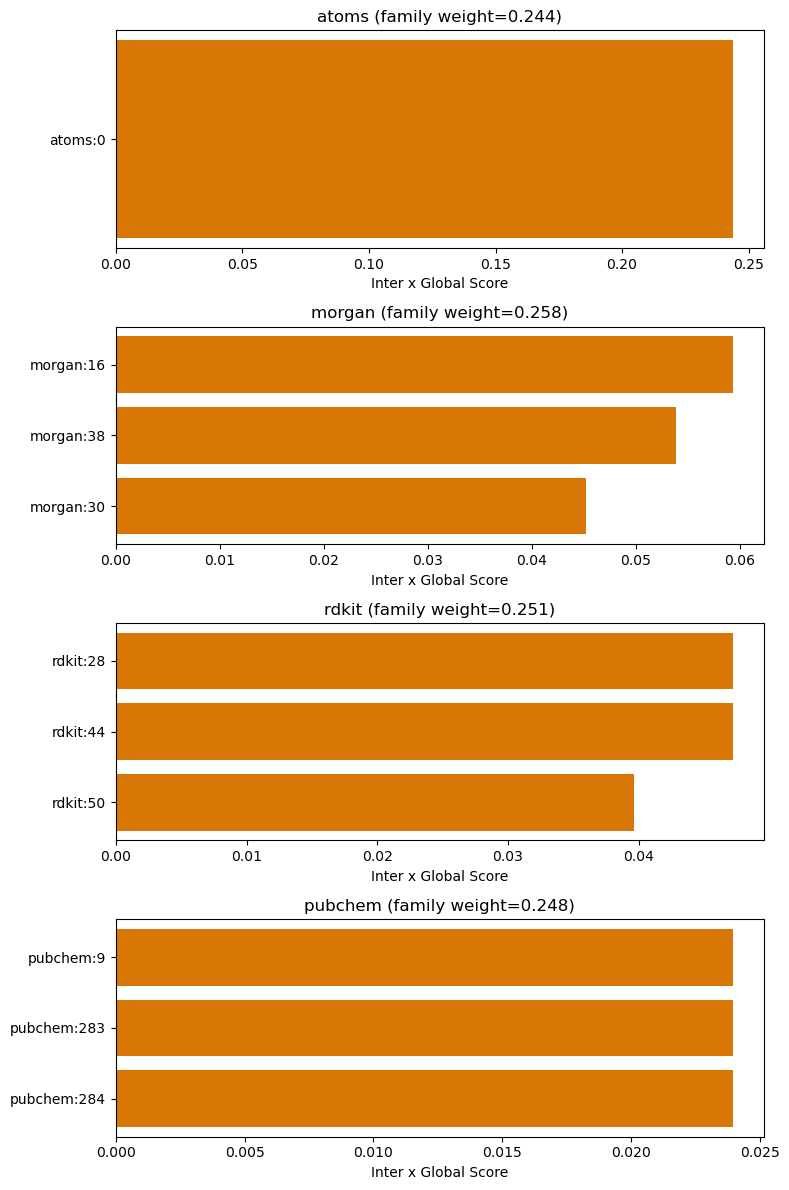

In [8]:
inter_fig = plot_fppool_inter_summary(first_explanation, top_k_bits=3)
plt.show()

### Global Family Weights

Global weights summarize how much each active family contributes to the pooled molecule embedding.

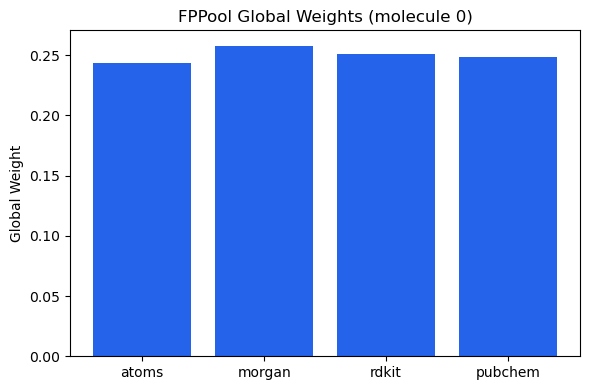

In [9]:
global_fig = plot_fppool_global_weights(first_explanation)
plt.show()

This notebook intentionally stays lightweight: it demonstrates the public interpretability API and visualization helpers without running a training loop. For a trained-model example, see `examples/fppool_benchmark.ipynb`.